In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:
fn = f"../results/OnlinePAFM/stochastic_PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_1200_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_DF_arr = data["pregrets_online"]
PREGRETS_random_DF_arr = data["pregrets_offline"]


fn = f"../results/RL/stochastic_online_pregrets_fqi.npz"
data = np.load(fn)
print(data)
PREGRETS_RL_arr = data["pregret_list_time"]
PREGRETS_random_RL_arr = data["pregret_list_notime"]
Ts_RL = data["t_list"] - 200

NpzFile '../results/RL/stochastic_online_pregrets_fqi.npz' with keys: pregret_list_notime, pregret_list_time, t_list


In [5]:
fn = f"../results/RL/stochastic_online_pregrets_sac_seeds_2.npz"
data = np.load(fn)
print(data)
PREGRETS_SAC_arr_2 = data["pregret_list_time"]
PREGRETS_random_SAC_arr_2 = data["pregret_list_notime"]
Ts_SAC_2 = data["t_list"]-200

NpzFile '../results/RL/stochastic_online_pregrets_sac_seeds_2.npz' with keys: pregret_list_notime, pregret_list_time, t_list


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_48680/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


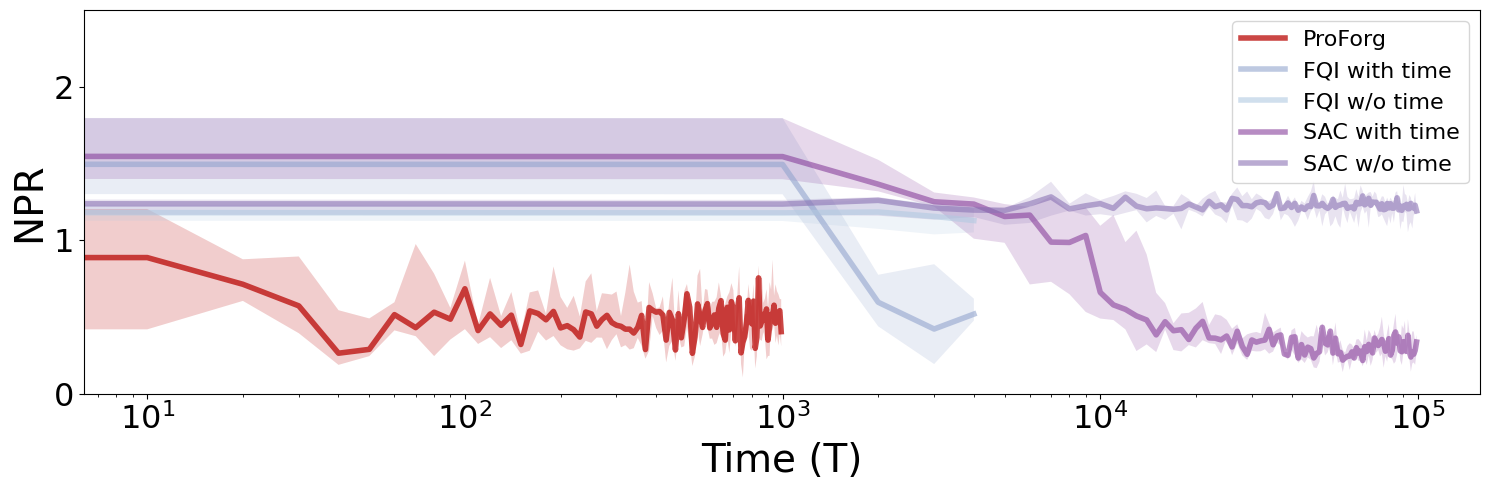

In [6]:
plt.figure(figsize=(15,5))

linewidth = 4
fontsize = 28
pvafm_df_offline, pafm_df, _,pvafm_df_online = get_close_colors("OrRd", start = 0.25, delta = 0.2 , n = 4) 
rl_fqi_notime,rl_fqi_time,sac_fqi_notime,sac_fqi_time = get_close_colors("BuPu", start=0.3, delta=0.15,n = 4)

colors = {"PAFM_RF_online": pvafm_df_online,
          "RL_FQI_notime":rl_fqi_notime,
          "RL_FQI_time":rl_fqi_time,
          "RL_SAC_notime":sac_fqi_notime,
          "RL_SAC_time":sac_fqi_time,
          }
step = 10

Ts_online = np.arange(200,1200,1) - 200
median = np.median(PREGRETS_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_DF_arr, 75, axis=0)
plt.plot(Ts_online[::step], median[:1000:step],color=colors["PAFM_RF_online"], lw = linewidth,alpha = 0.75,label = 'ProForg')
plt.fill_between(Ts_online[::step], q25[:1000:step], q75[:1000:step], color=colors["PAFM_RF_online"], alpha=0.20, edgecolor="none")


median = np.median(PREGRETS_RL_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_RL_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_RL_arr, 75, axis=0)
plt.plot(Ts_RL[1::step], median[1::step],color=colors["RL_FQI_time"], lw = linewidth,alpha = 0.6,label = 'FQI with time')
plt.fill_between(Ts_RL[1::step], q25[1::step], q75[1::step], color=colors["RL_FQI_time"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_RL_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_RL_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_RL_arr, 75, axis=0)
plt.plot(Ts_RL[1::step], median[1::step],color=colors["RL_FQI_notime"], lw = linewidth,alpha = 0.6,label = 'FQI w/o time')
plt.fill_between(Ts_RL[1::step], q25[1::step], q75[1::step], color=colors["RL_FQI_notime"], alpha=0.20, edgecolor="none")



median = np.median(PREGRETS_SAC_arr_2, axis=0)    
q25  = np.nanpercentile(PREGRETS_SAC_arr_2, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_SAC_arr_2, 75, axis=0)
plt.plot(Ts_SAC_2[1::step], median[1::step],color=colors["RL_SAC_time"], lw = linewidth,alpha = 0.6,label = 'SAC with time')
plt.fill_between(Ts_SAC_2[1::step], q25[1::step], q75[1::step], color=colors["RL_SAC_time"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_SAC_arr_2, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_SAC_arr_2, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_SAC_arr_2, 75, axis=0)
plt.plot(Ts_SAC_2[1::step], median[1::step],color=colors["RL_SAC_notime"], lw = linewidth,alpha = 0.6,label = 'SAC w/o time')
plt.fill_between(Ts_SAC_2[1::step], q25[1::step], q75[1::step], color=colors["RL_SAC_notime"], alpha=0.20, edgecolor="none")



xticks = [i for i in np.arange(20,1000,50)]+[i for i in np.arange(10000,5000,1000)]+[i for i in np.arange(200,100000,100)]
xticklabels = [str(v) if v in ['0',20,200,2000,20000,20000] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]

plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.xscale('log')
plt.ylim([0,2.5])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("NPR", fontsize = fontsize)
# plt.title('Proforg vs FQI',fontsize = fontsize)
plt.legend(loc = 'upper right',bbox_to_anchor=(1, 1),fontsize = fontsize-12)
plt.savefig('fig1_stochastic.png')
plt.tight_layout()